In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
 
import math
import numpy as np
import random

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.transforms as transforms
from torchvision.models import efficientnet_b0
from PIL import Image
from tqdm.notebook import tqdm
from syn2real_dataset import Syn2RealDataset
from string_to_xml_to_vec import string2vec, vec2string, vec2xml, pretty_print_xml
import numpy as np
import math
import os

# Add ../ as a directory to import from
import sys
sys.path.append('../')

from config import Config

In [2]:
eval_config = Config(mode='eval')
device = eval_config.device
# device = 'cpu'

In [3]:
from torch.utils.data import DataLoader
from plant_dataset import PlantDataset 

transform = transforms.Compose([
                        transforms.ToTensor(),
                        # transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])
image_size = 224

from plant_tokenizer import PAD_token

import pickle
# Check if the .plk file exists
dataset_dir = "../data/generated_dataset_Sep22_black"
saved_train_dataset_name = os.path.join(dataset_dir,"train_dataset.pkl")
saved_val_dataset_name = os.path.join(dataset_dir,"val_dataset.pkl")
if os.path.exists(saved_train_dataset_name) and False:
    if os.path.exists(saved_train_dataset_name):
        print("Loading plant dataset from .pkl file")
        with open(saved_train_dataset_name, "rb") as f:
            train_dataset = pickle.load(f)
        with open(saved_val_dataset_name, "rb") as f:
            val_dataset = pickle.load(f)
else:
    preload = False
    process_leaf = True
    train_dataset = PlantDataset(dataset_dir, plot=["000", "001", "002",], transform=transform, load_depth=False, preload=preload,
                                 process_leaf=process_leaf,
                                 image_size=image_size) 
    #train_dataset = PlantDataset("../_data/Syn2Real_cowpea/Syn2Real_cowpea", plot=["000"], transform=transform)
    val_dataset = PlantDataset(dataset_dir, plot=["003"], transform=transform, load_depth=False, preload=preload,
                               process_leaf=process_leaf,
                               image_size=image_size)

    if preload:
        with open(saved_train_dataset_name, "wb") as f:
            pickle.dump(train_dataset, f)
        with open(saved_val_dataset_name, "wb") as f:
            pickle.dump(val_dataset, f)

Total 4831 images and plant strings loaded
Total 1585 images and plant strings loaded


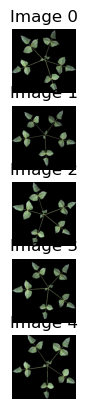

In [4]:
# Show some images
import matplotlib.pyplot as plt
import numpy as np
import torchvision

# train_dataset = PlantDataset("../_data/Syn2Real_cowpea/Syn2Real_cowpea", plot=["000", "001", "002", "003"], transform=transform,dry_run=True,use_depth=False)

import cv2
n = 5
for i in range(n):
    #image, vecs, _ = train_dataset[-i-1]
    image, vecs, _ = train_dataset[i]
    image = image.permute(1, 2, 0)
    image_rgb = image[:, :, :3]
    img = cv2.normalize(np.array(image_rgb.cpu()), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(5, 2, 2*i+1)
    plt.imshow(img)
    plt.title(f"Image {i}")
    plt.axis('off')

    if train_dataset.load_depth:
        image_depth = image[:, :, 3]
        img = cv2.normalize(np.array(image_depth.cpu()), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
        plt.subplot(5, 2, 2*i+2)
        plt.imshow(img, cmap='gray')
        plt.title("Depth")
        plt.axis('off')

In [5]:
from models.plightning import MainModule
# model = MainModule()
model = MainModule.load_from_checkpoint("../log/20241027_SeqEmbTest/version_1/checkpoints/best_epoch=198.ckpt")
model = model.to(device)
model.eval()
# model.freeze()

MainModule(
  (image_encoder): ViT_FeatureExtractor(
    (model): Dinov2Model(
      (embeddings): Dinov2Embeddings(
        (patch_embeddings): Dinov2PatchEmbeddings(
          (projection): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (encoder): Dinov2Encoder(
        (layer): ModuleList(
          (0-11): 12 x Dinov2Layer(
            (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
            (attention): Dinov2Attention(
              (attention): Dinov2SelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.0, inplace=False)
              )
              (output): Dinov2SelfOutput(
                (dense): Linear(in_features=768, out_features=768, bias=True)


In [6]:
from plant_tokenizer import params_SOS_token_padded, SOS_token, EOS_token
from plant_tokenizer import token2vec
from plant_tokenizer import vec2token
from models.model import get_tgt_mask
from plant_dataset import collate_fn

import torch.nn.functional as F

# 모델이 입력 이미지와 Seqence 에 따라 서로 다른 Embedding 을 만드는지 확인해보기
from tqdm.auto import tqdm
from plant_tokenizer import generate_noise_plant_tokens
stages = ["003","010","016","023"]
test_dataset = PlantDataset("../data/generated_dataset_Sep22_black_subset", plot=["004"], stages=stages,
                            transform=transform, load_depth=False, preload=False, process_leaf=True, image_size=image_size)
gen_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)
model.eval()
img_emb_total = []
seq_emb_total = []
growth_stages = []
for idx, (image, out, lengths) in enumerate(tqdm(gen_dataloader)):
    if image.dim() == 3:
        image = image.unsqueeze(0)
    # Get image name
    file_name = test_dataset.image_paths[idx]
    # Get growth stage
    growth_stage = file_name.split('_')[2]
    growth_stages.append(growth_stage)
    #print(test_dataset.image_paths[idx])
    # print("Ground truth")
    # print(test_dataset.plant_string_raw)

    image = image.to(device)
    out = out.to(device)
    # Plot the image
    # Draw the image
    image_vis = image.squeeze(0).permute(1,2,0).cpu().numpy()
    img = cv2.normalize(np.array(image_vis), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    #img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    image_vis = img.astype(np.uint8)
    # plt.imshow(image_vis)
    with torch.no_grad():

        # Check embeddings
        img_emb = model.get_image_embedding(image)
        y_expected = out[:, 1:]
        #y_expected = out2[:, 1:]
        label = y_expected[:, :, 0].long()
        label_onehot = F.one_hot(label, num_classes=model.seq_dim).float()
        y_expected_seq = torch.cat((label_onehot, y_expected[:, :, 1:]), dim=2)

        # Add noise
        if 0:
            noise = generate_noise_plant_tokens(y_expected_seq, 0.1)
            y_expected_seq = y_expected_seq + noise


        seq_emb = model.SeqEmbeddingModel(y_expected_seq.to(device))
        
        img_emb_total.append(img_emb)
        seq_emb_total.append(seq_emb)

img_emb_total = torch.cat(img_emb_total, dim=0)
seq_emb_total = torch.cat(seq_emb_total, dim=0)

Total 77 images and plant strings loaded


  0%|          | 0/77 [00:00<?, ?it/s]

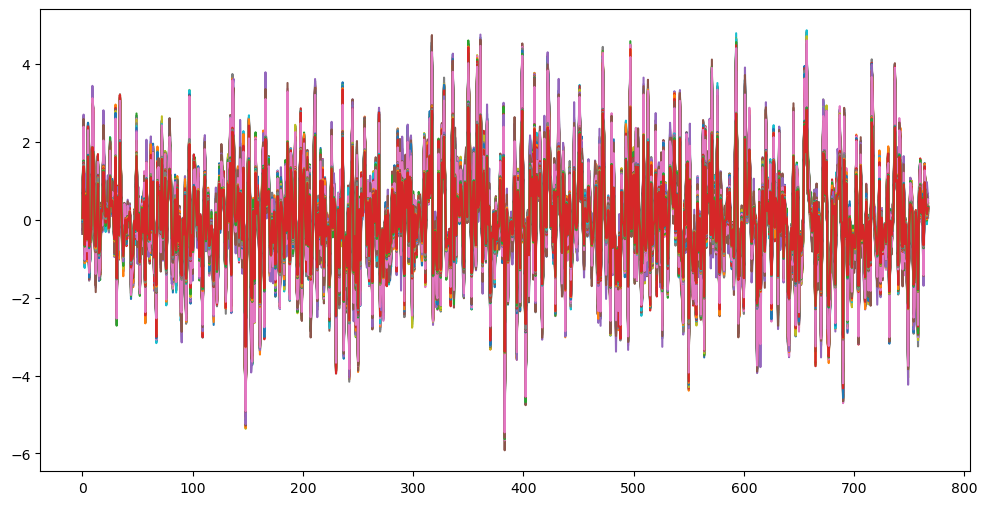

In [7]:
# Plot the embeddings. x axis = 0 - 768 (embedding size)
# y axis = 0 - 1
img_emb_total_array = np.array(img_emb_total.cpu())
seq_emb_total_array = np.array(seq_emb_total.cpu())

# Plot the embeddings
plt.figure(figsize=(12, 6))
plt.plot(img_emb_total_array.T, label="Image Embedding")
plt.plot(seq_emb_total_array.T, label="Seq Embedding")

In [8]:
import subprocess
import shutil

img_emb_total_array = np.array(img_emb_total.cpu())
seq_emb_total_array = np.array(seq_emb_total.cpu())

# Plot the embeddings and make a gif from multiple images
plt.figure(figsize=(12, 6))
temp_folder = "temp"
os.makedirs(temp_folder, exist_ok=True)

# Get min and max values
min_val = min(np.min(img_emb_total_array), np.min(seq_emb_total_array))
max_val = max(np.max(img_emb_total_array), np.max(seq_emb_total_array))

for i in range(len(img_emb_total_array)):
    plt.plot(img_emb_total_array[i], label=f"Image Embedding {i}")
    plt.plot(seq_emb_total_array[i], label=f"Seq Embedding {i}")
    plt.ylim(min_val, max_val)
    plt.xlabel("Embedding Dimensions (0-767)")
    plt.ylabel("Values")
    plt.legend(loc='upper right')

    # Save the plot
    plt.savefig(f"{temp_folder}/embedding_{i}.png")

    # Clear the plot
    plt.clf()

# Make a video using FFmpeg
video_filename = 'embedding.mp4'
ffmpeg_command = [
    'ffmpeg', '-y', '-framerate', '5', '-i', f'{temp_folder}/embedding_%d.png',
    '-c:v', 'libx264', '-pix_fmt', 'yuv420p', video_filename
]
subprocess.run(ffmpeg_command, stdout=subprocess.PIPE, stderr=subprocess.PIPE)

# Clean up
# shutil.rmtree(temp_folder)

# Display the video
from IPython.display import Video
Video(video_filename)

<Figure size 1200x600 with 0 Axes>

In [9]:
import subprocess
import shutil

img_emb_total_array = np.array(img_emb_total.cpu())
seq_emb_total_array = np.array(seq_emb_total.cpu())

# Plot the embeddings and make a gif from multiple images
plt.figure(figsize=(12, 6))
temp_folder = "temp"
os.makedirs(temp_folder, exist_ok=True)

# Get min and max values
min_val = min(np.min(img_emb_total_array), np.min(seq_emb_total_array))
max_val = max(np.max(img_emb_total_array), np.max(seq_emb_total_array))

for i in range(len(img_emb_total_array)):
    if 0:
        plt.plot(img_emb_total_array[i], label=f"Image Embedding {i}")
        plt.plot(seq_emb_total_array[i], label=f"Seq Embedding {i}")
    else:
        # Plot a scatter plot
        plt.scatter(img_emb_total_array[i], seq_emb_total_array[i], label=f"data {i}")
    plt.xlim(np.min(img_emb_total_array), np.max(img_emb_total_array))
    plt.ylim(np.min(seq_emb_total_array), np.max(seq_emb_total_array))
    plt.legend(loc='upper right')
    plt.xlabel("Image Embedding")
    plt.ylabel("Seq Embedding")
    # Save the plot
    plt.savefig(f"{temp_folder}/embedding_{i}.png")

    # Clear the plot
    plt.clf()


# Make a video using FFmpeg
video_filename = 'embedding_scatter.mp4'
ffmpeg_command = [
    'ffmpeg', '-y', '-framerate', '5', '-i', f'{temp_folder}/embedding_%d.png',
    '-c:v', 'libx264', '-pix_fmt', 'yuv420p', video_filename
]
subprocess.run(ffmpeg_command, stdout=subprocess.PIPE, stderr=subprocess.PIPE)

# Clean up
# shutil.rmtree(temp_folder)

# Display the video
from IPython.display import Video
Video(filename=video_filename)

<Figure size 1200x600 with 0 Axes>

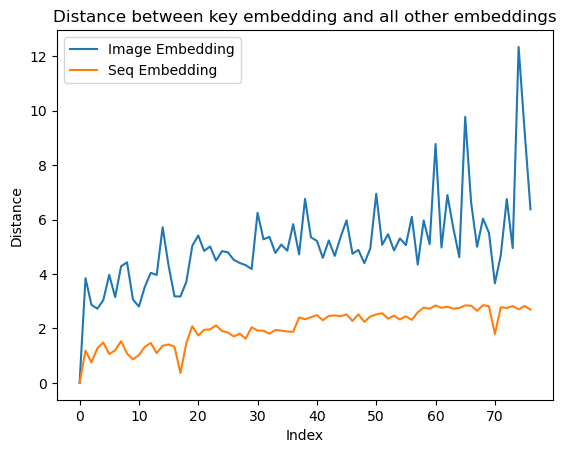

In [10]:
key_embedding = img_emb_total[0]

# Calculate the distance between the key embedding and all other embeddings
distances = []
for emb in img_emb_total:
    dist = torch.dist(key_embedding, emb, p=2)
    distances.append(dist)
distances = torch.tensor(distances)
# Plot the distances

plt.plot(distances.cpu())
plt.xlabel("Index")
plt.ylabel("Distance")
plt.title("Distance between key embedding and all other embeddings")

# Repeat for the sequence embeddings
key_embedding = seq_emb_total[0]

# Calculate the distance between the key embedding and all other embeddings
distances = []
for emb in seq_emb_total:
    dist = torch.dist(key_embedding, emb, p=2)
    distances.append(dist)
distances = torch.tensor(distances)
# Plot the distances

plt.plot(distances.cpu())
plt.xlabel("Index")
plt.ylabel("Distance")
plt.title("Distance between key embedding and all other embeddings")
plt.legend(["Image Embedding", "Seq Embedding"])

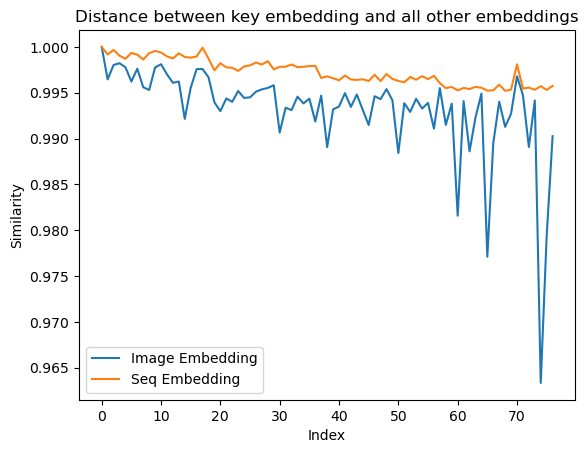

In [11]:
key_embedding = img_emb_total[0]

# Calculate the Cosine similarity between the key embedding and all other embeddings
distances = []
for emb in img_emb_total:
    dist = torch.nn.functional.cosine_similarity(key_embedding, emb, dim=0)
    distances.append(dist)
distances = torch.tensor(distances)
# Plot the distances

plt.plot(distances.cpu())
plt.xlabel("Index")
plt.ylabel("Similarity")
plt.title("Distance between key embedding and all other embeddings")

# Repeat for the sequence embeddings
key_embedding = seq_emb_total[0]

# Calculate the distance between the key embedding and all other embeddings
distances = []
for emb in seq_emb_total:
    dist = torch.nn.functional.cosine_similarity(key_embedding, emb, dim=0)
    distances.append(dist)
distances = torch.tensor(distances)
# Plot the distances

plt.plot(distances.cpu())
plt.xlabel("Index")
plt.ylabel("Similarity")
plt.title("Distance between key embedding and all other embeddings")

# Add legend
plt.legend(["Image Embedding", "Seq Embedding"])

/home/lion397/codes/Image2PlantArchitecture/.env/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


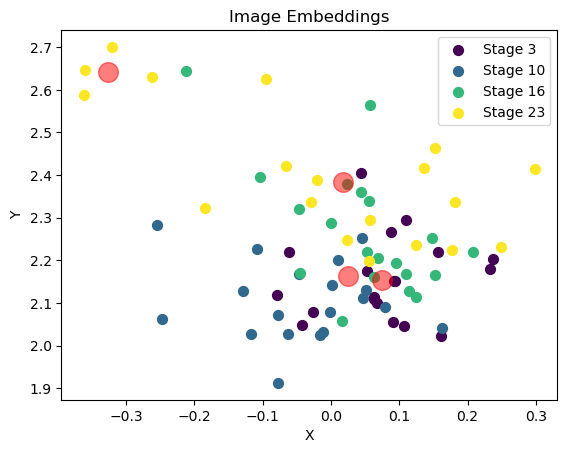

In [12]:
# Cluster the images based on the image embeddings
from sklearn.cluster import KMeans

# Cluster the image embeddings
kmeans = KMeans(n_clusters=4, random_state=0).fit(img_emb_total_array)

# Get the cluster labels
if 0:
    cluster_labels = kmeans.labels_
else:
    # Convert growth stages to colors
    growth_stages = np.array(growth_stages)
    growth_stages = growth_stages.astype(int)
    cluster_labels = growth_stages

# Plot the clusters
# plt.figure(figsize=(10, 8))
unique_labels = np.unique(cluster_labels)
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))

# Plot the clusters
for label, color in zip(unique_labels, colors):
    plt.scatter(img_emb_total_array[cluster_labels == label, 0], img_emb_total_array[cluster_labels == label, 1], 
                c=[color], label=f'Stage {label}', s=50)

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', s=200, alpha=0.5)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Image Embeddings")
plt.legend()
# Put legend for growth stages
plt.show()



Total 368 images and plant strings loaded


/tmp/ipykernel_2491648/1899217994.py:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  out = torch.tensor(out).to(device)


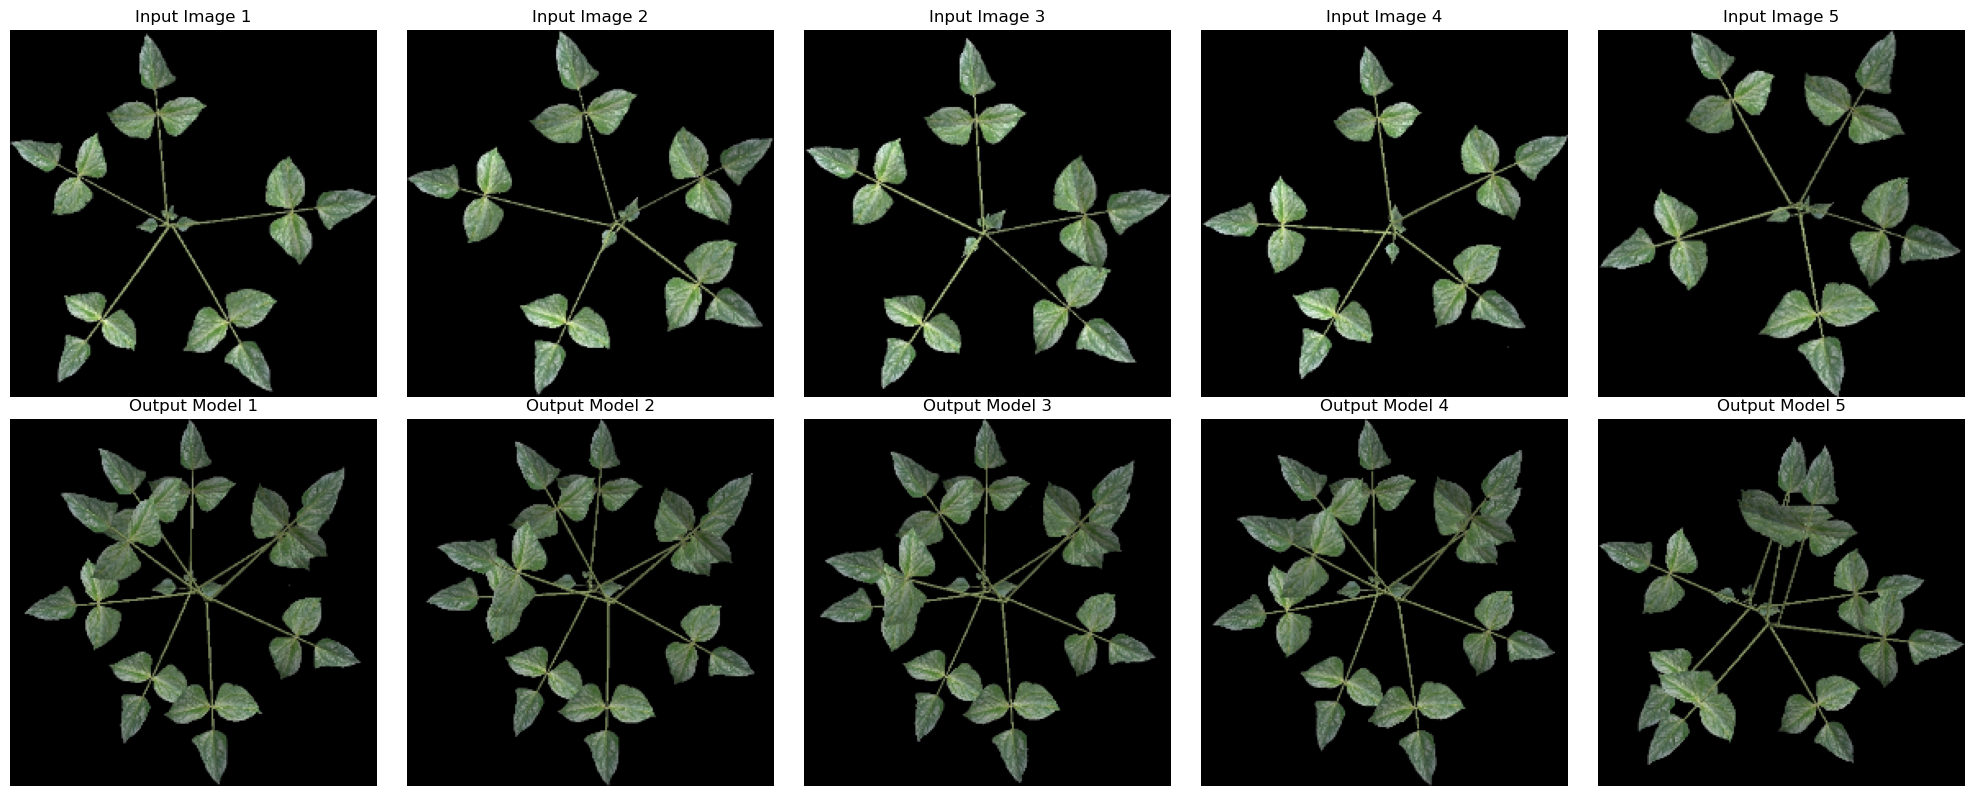

In [18]:
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from plant_tokenizer import params_SOS_token_padded, SOS_token, EOS_token
from models.model import get_tgt_mask
from plant_dataset import collate_fn, PlantDataset
from image_process import process_leaf_image
from plantstring2model import plantstring2model

# Initialize the model
p2m = plantstring2model(program_path="PlantString2Model/build", program_name="PlantString2Model", display=":11.0", height=1.0, background_path="assets/black.png")

# Define stages and dataset
stages = ["003", "010", "016", "023"]
test_dataset = PlantDataset("../data/generated_dataset_Sep22_black", plot=["004"], stages=stages[0],
                            transform=transform, load_depth=False, preload=False, process_leaf=True, image_size=image_size)
gen_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=True, collate_fn=collate_fn)

# Prepare the figure
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

# Create temp folder
temp_folder = "temp"
os.makedirs(temp_folder, exist_ok=True)


# Process and display 10 images
model.eval()
for idx, (image, out, lengths) in enumerate(gen_dataloader):
    if idx >= 5:
        break

    if image.dim() == 3:
        image = image.unsqueeze(0)

    image = image.to(device)
    image_vis = image.squeeze(0).permute(1, 2, 0).cpu().numpy()
    img = cv2.normalize(np.array(image_vis), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    image_vis = img.astype(np.uint8)
    
    with torch.no_grad():
        result = model.generate(image)
    out = torch.tensor(out).to(device)
    ground_truth = out.squeeze(0).tolist()

    plant_vec = token2vec(result)
    plant_string = vec2string([plant_vec])

    plant_string_file_name = f"temp/plant_string_{idx}.txt"
    with open(plant_string_file_name, "w") as f:
        f.write(plant_string)

    p2m.run(in_plantstring_path=os.path.abspath(plant_string_file_name), output_path=os.path.abspath(f"output_{idx}"))
    generated_image_path = f"output_{idx}/plant_string_{idx}_top.jpeg"

    img = cv2.imread(generated_image_path)
    leaf_area, plant_width, plant_height, leaf_img, _ = process_leaf_image(img, sqaure_crop=True, thr=0.2)
    img = cv2.resize(leaf_img, (image_size, image_size))

    row, col = divmod(idx, 5)
    axes[row, col].imshow(image_vis[:, :, 0:3])
    axes[row, col].set_title(f"Input Image {idx + 1}")
    axes[row, col].axis('off')

    axes[row + 1, col].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[row + 1, col].set_title(f"Output Model {idx + 1}")
    axes[row + 1, col].axis('off')

plt.tight_layout()
plt.show()

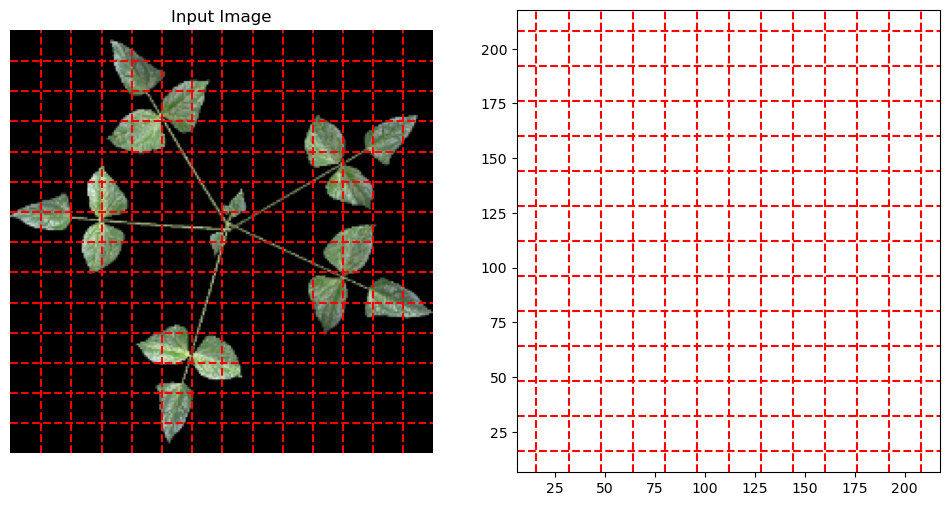

In [14]:
# Draw a 14x14 grid on the image_vis[:,:,0:3]
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image_vis[:,:,0:3])
axes[0].set_title("Input Image")
axes[0].axis('off')

for i in range(1, 14):
    axes[0].axvline(i*16, color='r', linestyle='--')
    axes[0].axhline(i*16, color='r', linestyle='--')
    axes[1].axvline(i*16, color='r', linestyle='--')
    axes[1].axhline(i*16, color='r', linestyle='--')
plt.show()

['0 {6.350980,304.165878,127.436843,88.986725,unifoliate}', 'Internode(0.025144,0.000936,14.901984,157.483317)', 'Petiole(0.012141,0.000489,77.127855)', 'Leaf(0.027747,358.230805,5.629646,0.427531)', '[{1.666531,2.120087,87.034106,115.179968,trifoliate}', 'Internode(0.020783,0.002462,32.499683,156.202629)', 'Petiole(0.117172,0.001545,53.402363)', 'Leaf(0.049328,359.583592,4.277350,6.497680)', 'Internode(0.018840,0.001415,25.820799,150.315962)', 'Petiole(0.115989,0.001419,54.009291)', 'Leaf(0.049804,355.132597,4.707963,6.521426)', 'Internode(0.019491,0.001241,24.870215,148.826489)', 'Petiole(0.115420,0.001368,54.211652)', 'Leaf(0.049729,354.669691,4.401139,6.323002)', 'Internode(0.019861,0.001206,24.677152,149.080982)', 'Petiole(0.115088,0.001348,54.129618)', 'Leaf(0.049669,354.460661,4.127394,6.194589)', 'Internode(0.020126,0.001204,24.057075,148.224326)', 'Petiole(0.114899,0.001342,54.032370)', 'Leaf(0.049618,354.323869,3.890063,6.109914)', 'Internode(0.019923,0.001341,24.067888,145.7

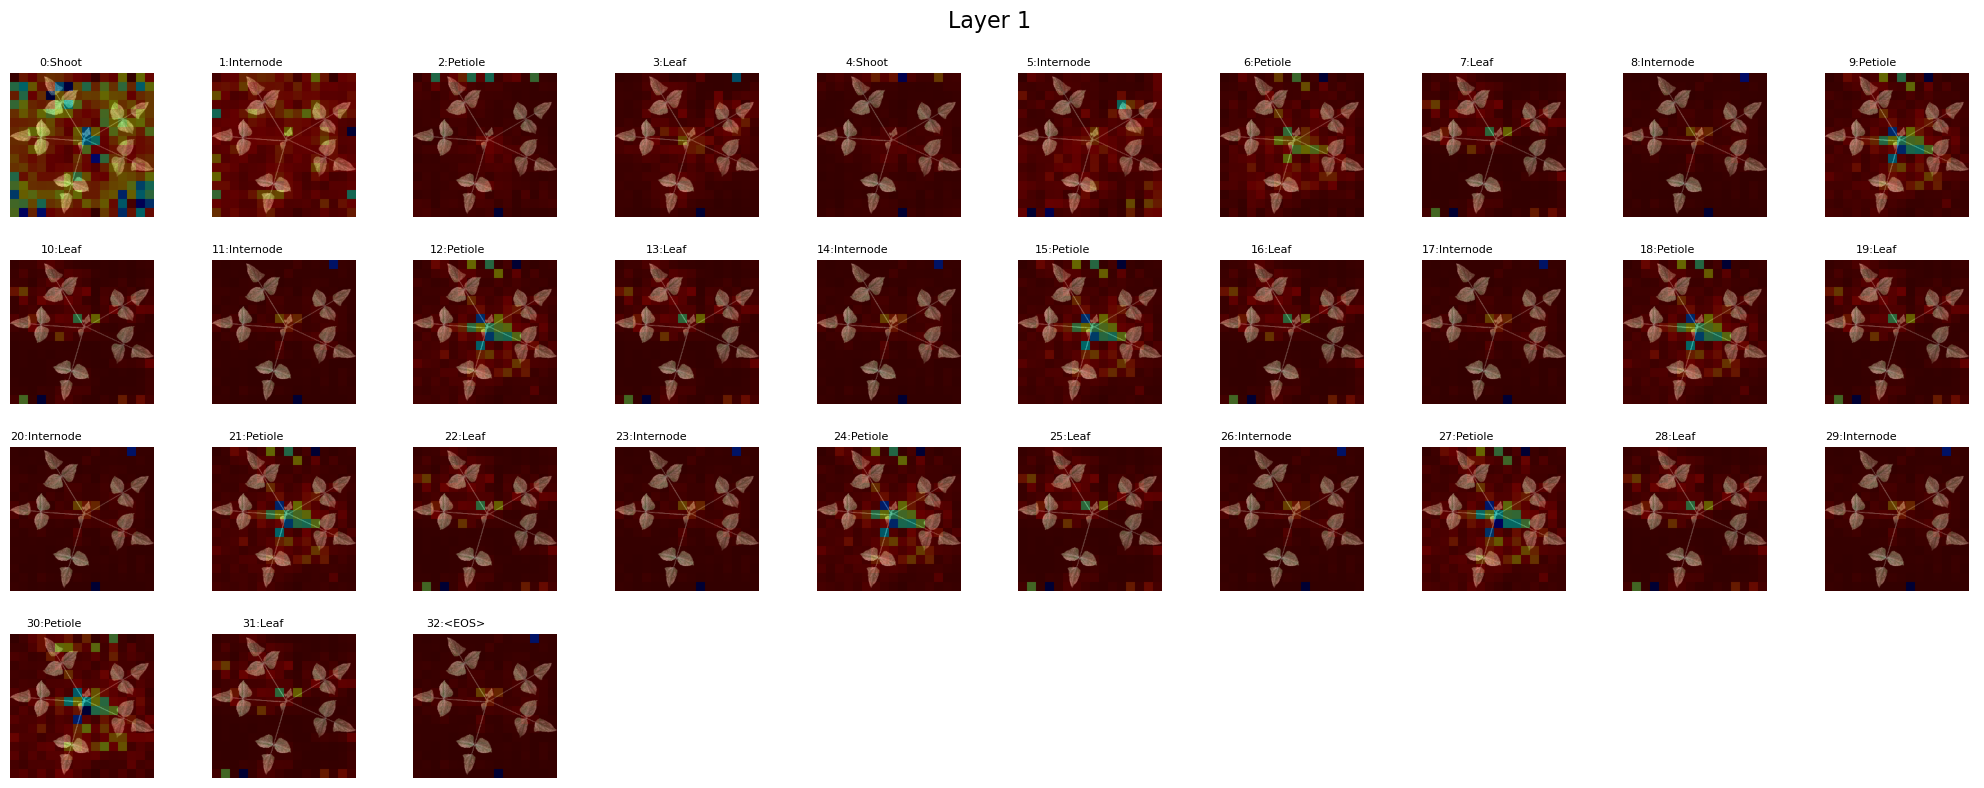

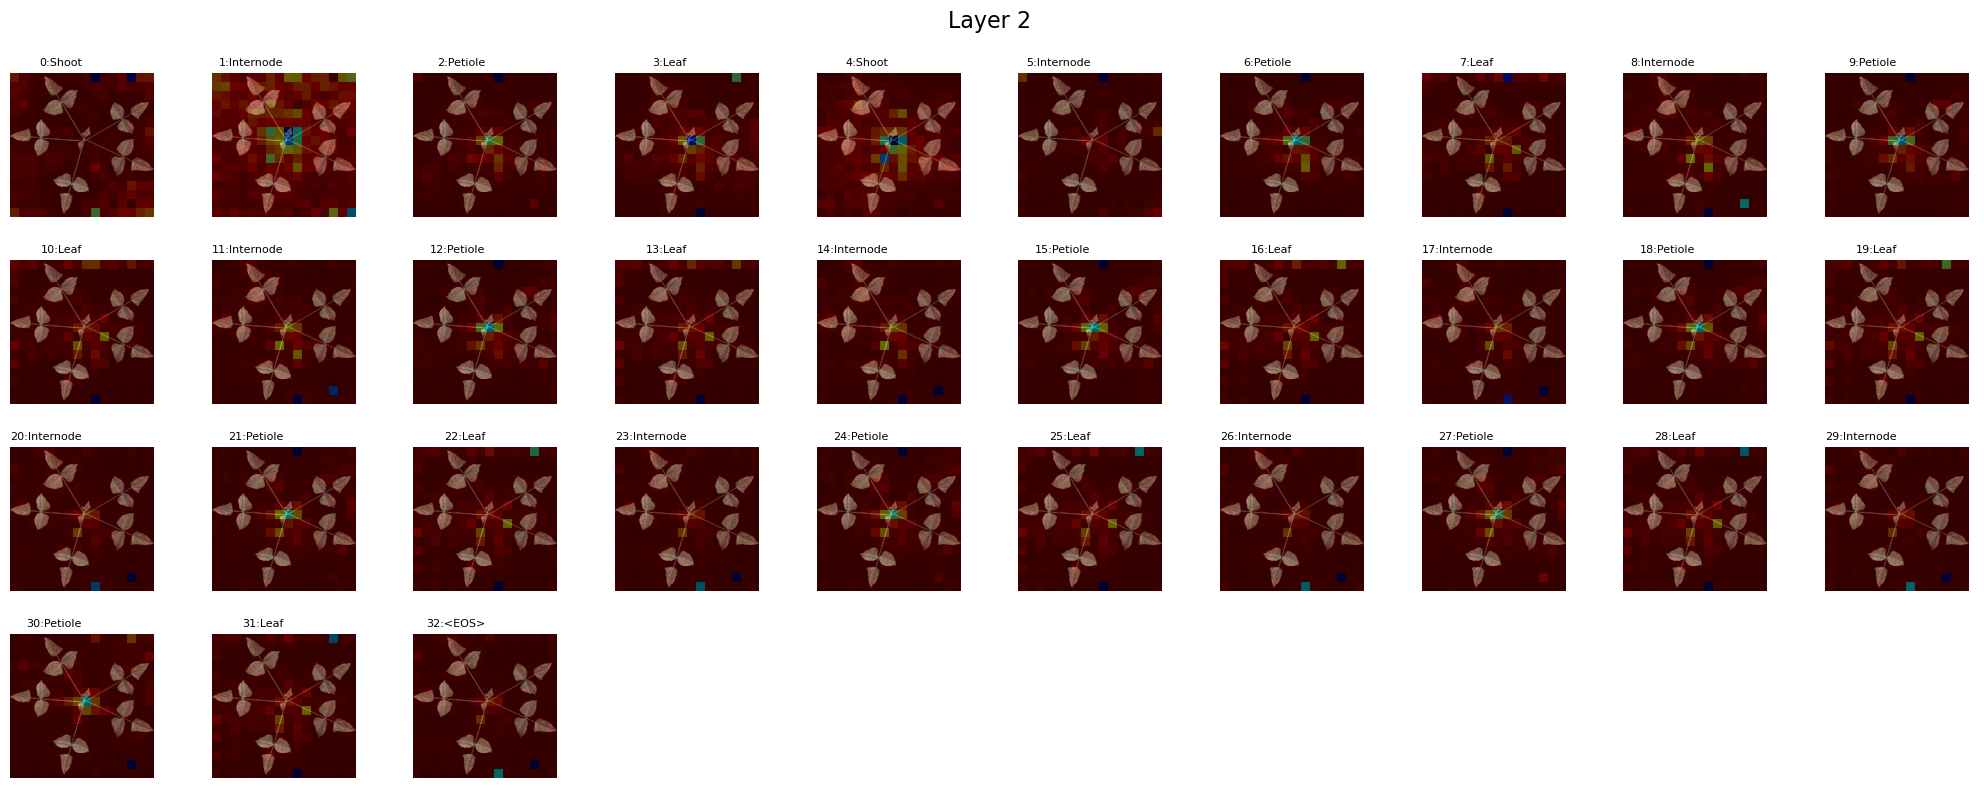

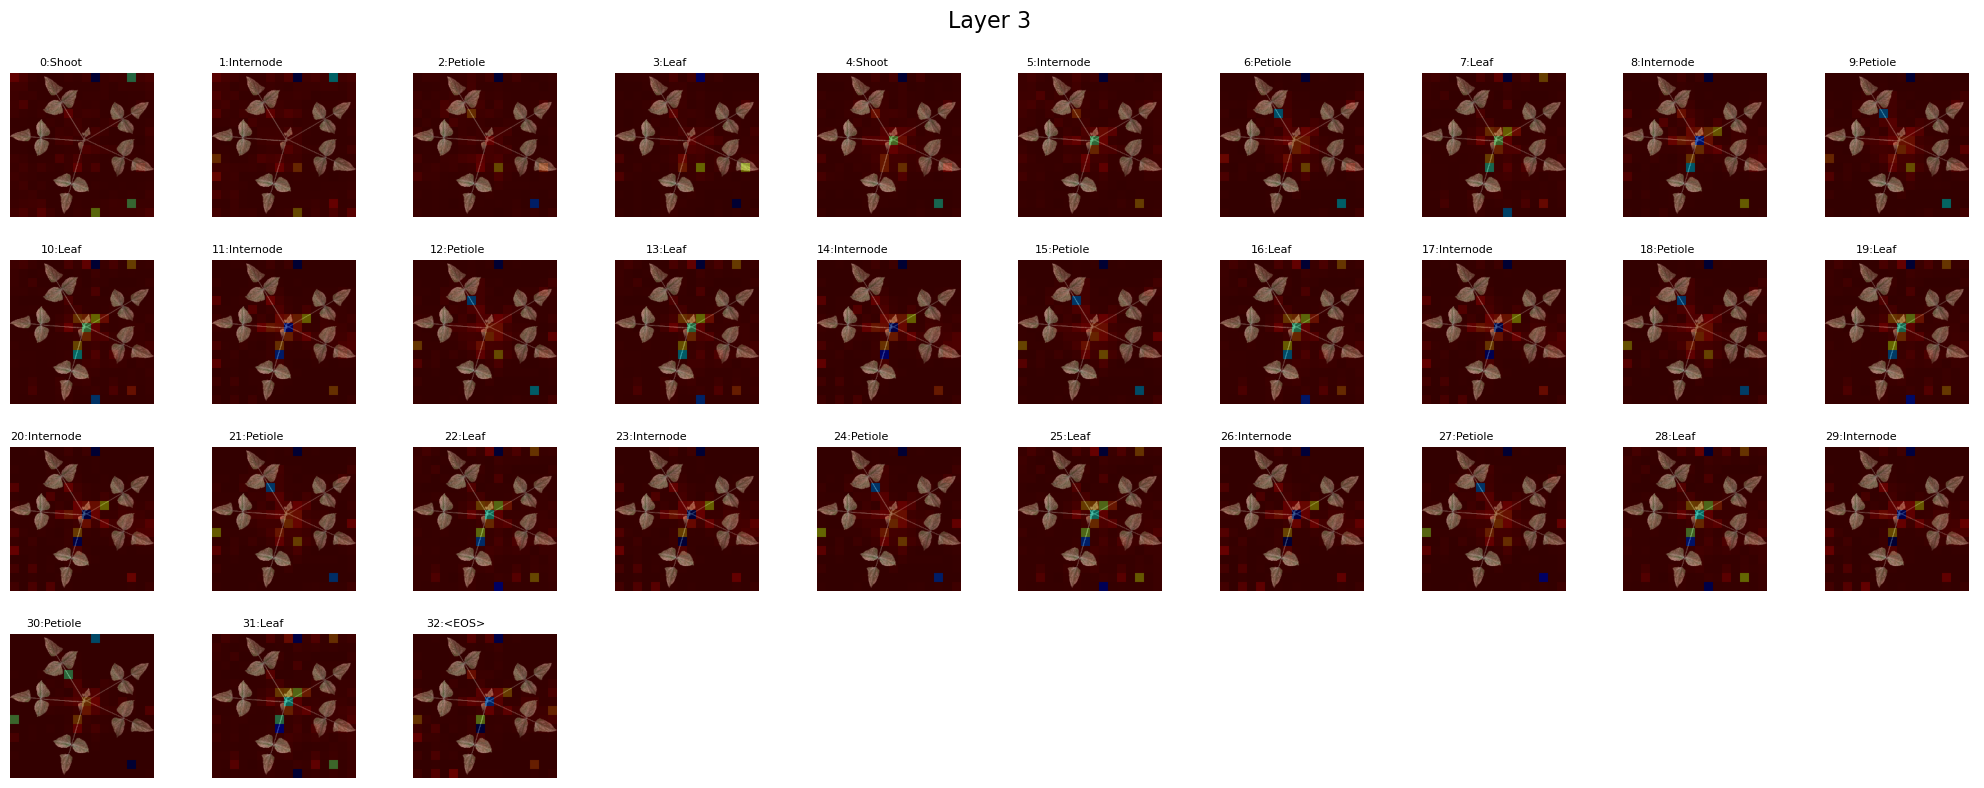

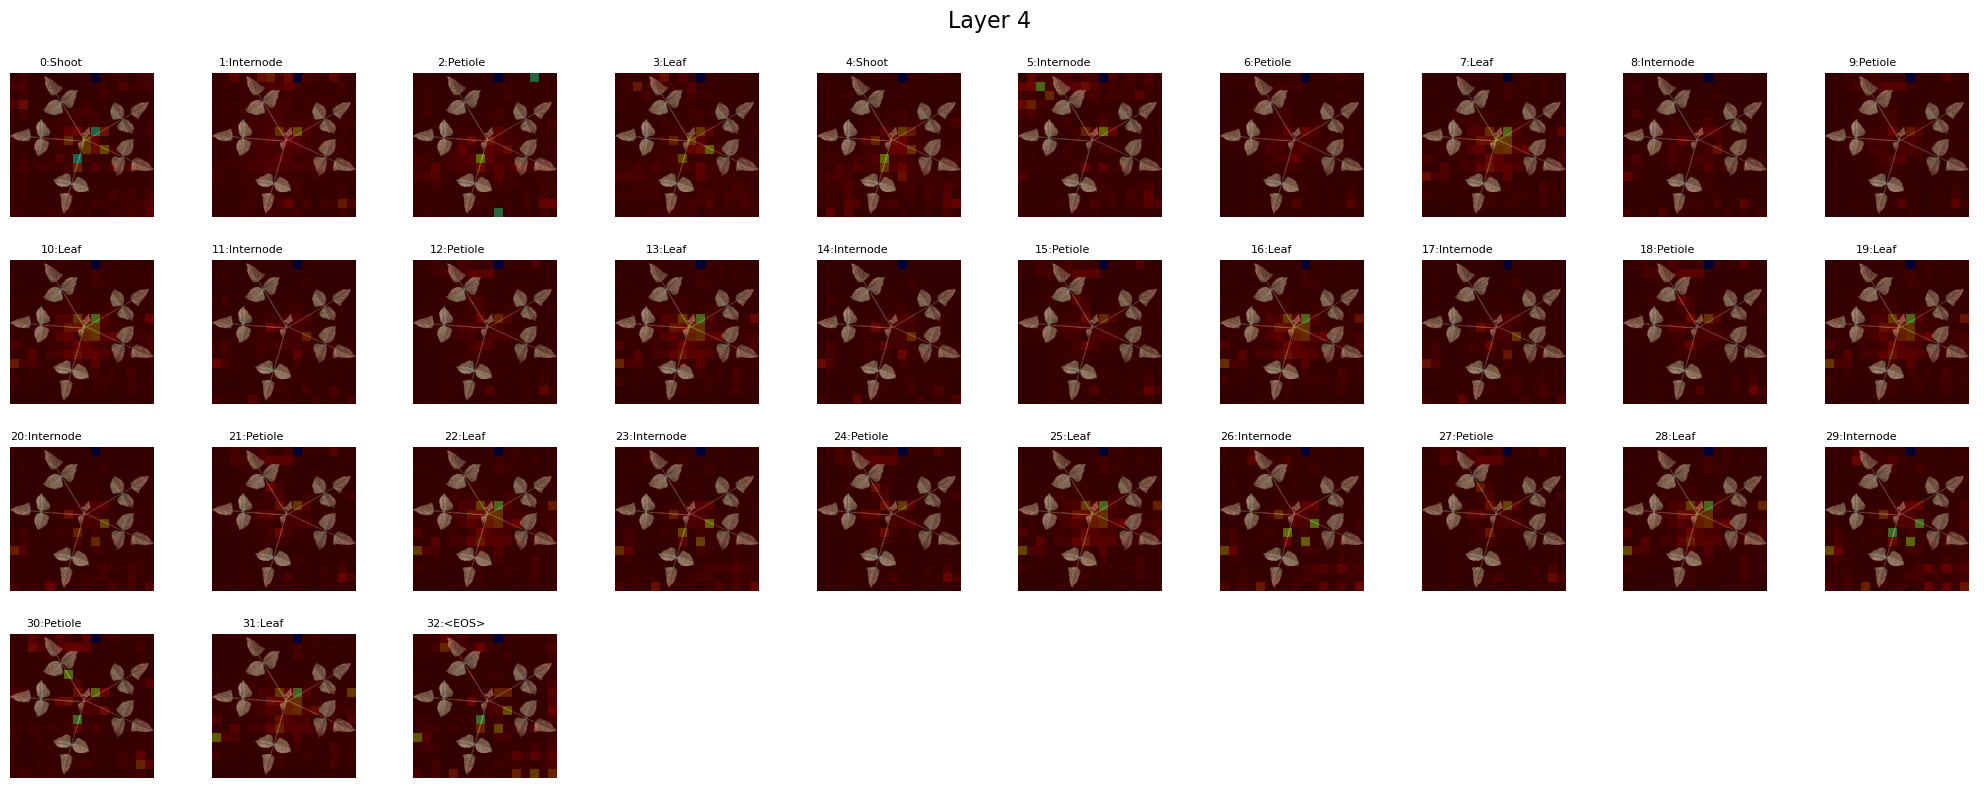

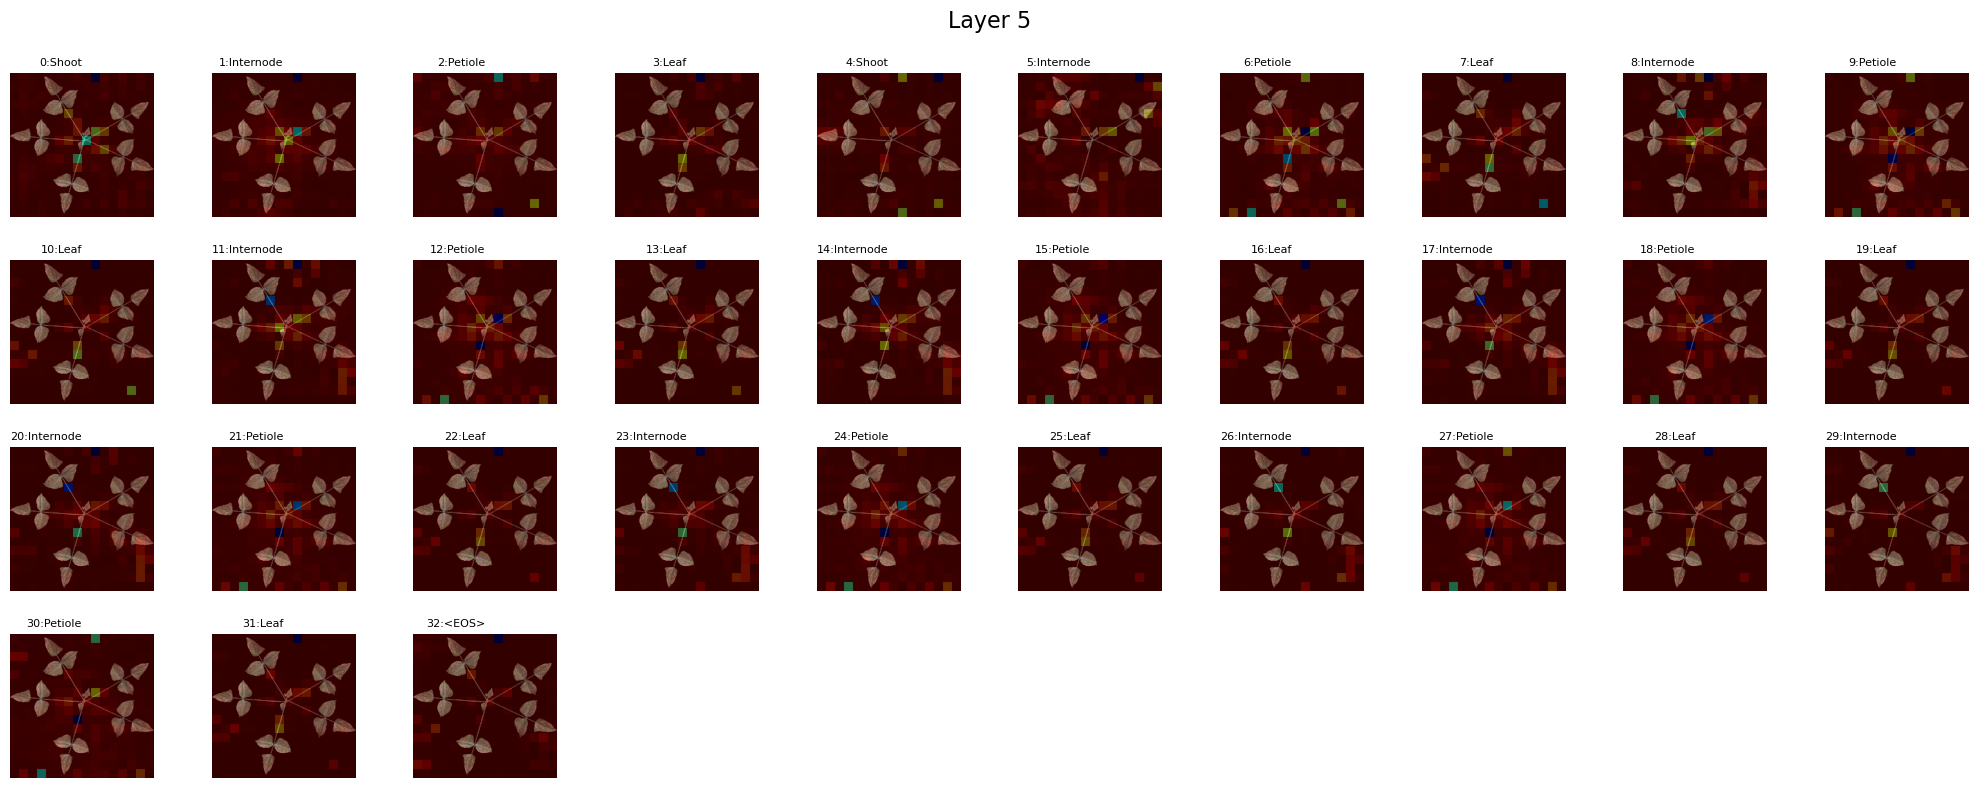

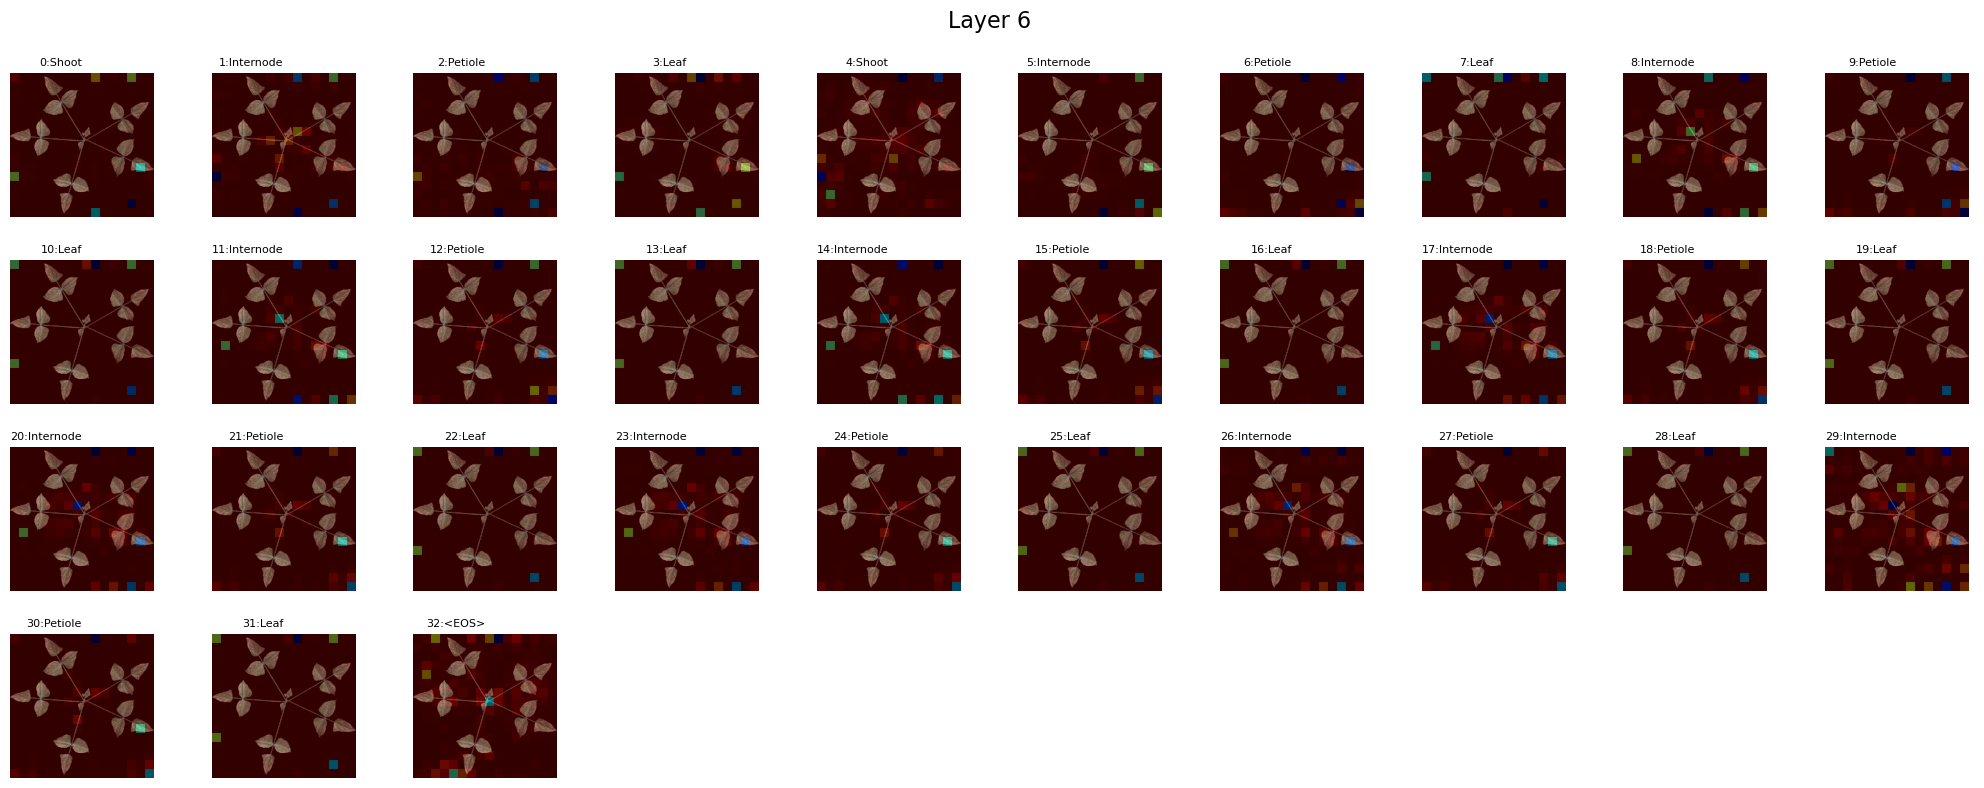

In [15]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import cv2

from utils import visualize_attention
from string_to_xml_to_vec import plant_string2words
from plant_tokenizer import token2vec

# Visualize attention
# Example words
plant_vec = token2vec(result)
plant_string = vec2string([plant_vec])

words = plant_string2words(plant_string)
print(words)

if 0:
    # Add <SOS> to the beginning of the list of words
    words = ["<SOS>"] + words
else:
    # Add <EOS> to the end of the list of words
    words = words + ["<EOS>"]

def shorten_title(title, max_length=10):
    """Shorten the title if it is too long."""
    if "foliate" in title:
        title = "Shoot"
    elif "Internode" in title:
        title = "Internode"
    elif "Petiole" in title:
        title = "Petiole"
    elif "Leaf" in title:
        title = "Leaf"
    return title

# Create a word_dimx3 subplot
multihead_attn_weights = model.sequence_decoder.multihead_attn_weights
image_dict = {}
num_cols = 10  # Number of images per row

for layer_index in range(len(multihead_attn_weights)):
    num_rows = (len(words) + num_cols - 1) // num_cols  # Calculate the number of rows needed
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 2, num_rows * 2))
    fig.suptitle(f'Layer {layer_index + 1}', fontsize=16)
    
    for word_index in range(len(words)):
        row = word_index // num_cols
        col = word_index % num_cols
        overlay = visualize_attention(image_vis, multihead_attn_weights, words, word_index, layer_index, interpolation=cv2.INTER_NEAREST)
        image_dict[(layer_index, word_index)] = overlay
        axes[row][col].imshow(overlay)
        axes[row][col].axis('off')
        short_title = shorten_title(words[word_index])
        axes[row][col].set_title(f"{word_index}:{short_title}", rotation=0, ha='right', fontsize=8)
    
    # Hide any unused subplots
    for i in range(len(words), num_rows * num_cols):
        row = i // num_cols
        col = i % num_cols
        axes[row][col].axis('off')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9, wspace=0.3, hspace=0.3)  # Adjust the top to make room for the suptitle and add space between subplots
    plt.show()

In [16]:
# Create a output folder
output_dir = "attention_output"
# Remove the folder if it exists
if os.path.exists(output_dir):
    import shutil
    shutil.rmtree(output_dir)
if not os.path.exists(output_dir):
    os.makedirs(output_dir)



# Save the attention images
for key, img in image_dict.items():
    layer_index, word_index = key
    img_vis = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    file_name = f"layer_{layer_index}_word_{word_index}_{words[word_index]}.png"
    file_path = os.path.join(output_dir, file_name)
    cv2.imwrite(file_path, img_vis)